In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [60]:
df = pd.read_csv('data/stud.csv')

In [61]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [62]:
df.shape

(1000, 8)

In [63]:
# Check for missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [64]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [65]:
#check null values and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [66]:
#checking the number of unique values in each column
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [67]:
#check stats of the data
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [68]:
#exploring data
print("Categories in 'gender' variable:   ",end="")
print(df['gender'].unique())
print("Categories in 'race_ethnicity' variable:   ",end="")
print(df['race_ethnicity'].unique())
print("Categories in 'parental_level_of_education' variable:   ",end="")
print(df['parental_level_of_education'].unique())
print("Categories in 'lunch' variable:   ",end="")
print(df['lunch'].unique())
print("Categories in 'test_preparation_course' variable:   ",end="")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:   <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' variable:   <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:   <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test_preparation_course' variable:   <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [69]:
#define numerical and categorical columns
numerical_features= [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

#print coloumns
print('We have {} numerical features : {}'.format(len(numerical_features),numerical_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features),categorical_features))

We have 8 numerical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']

We have 0 categorical features : []


In [70]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average']= df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [71]:
reading_full =df[df['reading_score'] == 100]['average'].count()
writing_full =df[df['writing_score'] == 100]['average'].count()
math_full =df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in reading: {reading_full}')
print(f'Number of students with full marks in writing: {writing_full}')
print(f'Number of students with full marks in math: {math_full}')   

Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


In [72]:
reading_less_20=df[df['reading_score'] < 20]['average'].count()
writing_less_20=df[df['writing_score'] < 20]['average'].count()     
math_less_20=df[df['math_score'] < 20]['average'].count()

print(f'Number of students with less than 20 marks in reading: {reading_less_20}')
print(f'Number of students with less than 20 marks in writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in math: {math_less_20}')

Number of students with less than 20 marks in reading: 1
Number of students with less than 20 marks in writing: 3
Number of students with less than 20 marks in math: 4


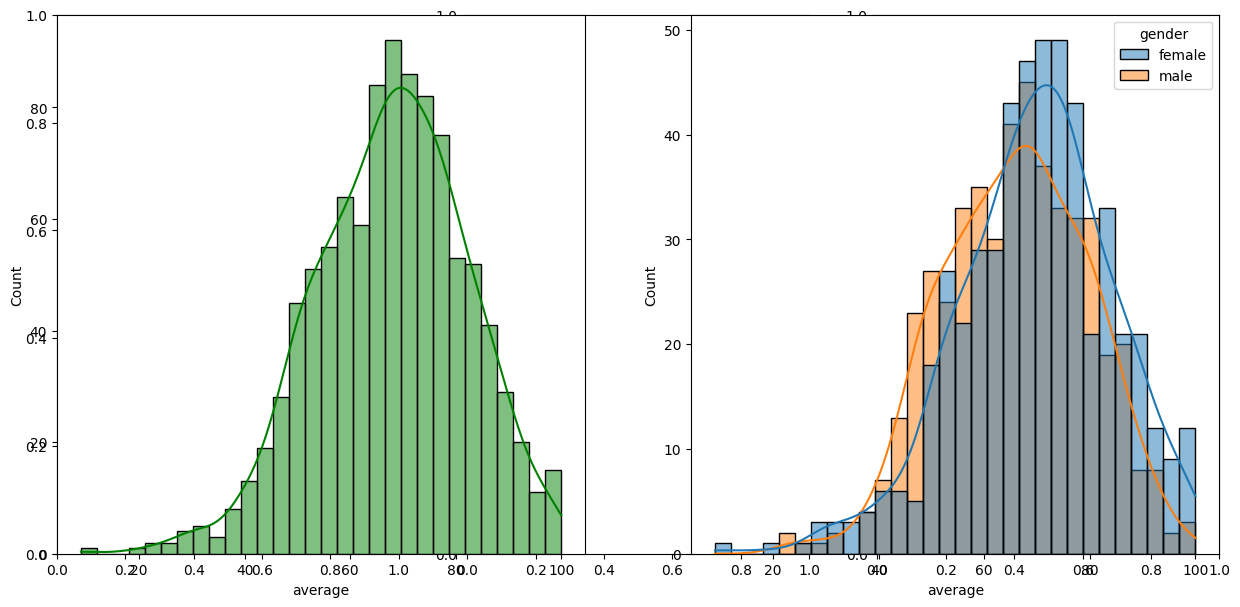

In [73]:
#histogram & KDE
fig, ax = plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='average',bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average',bins=30, kde=True, hue='gender')
plt.show()

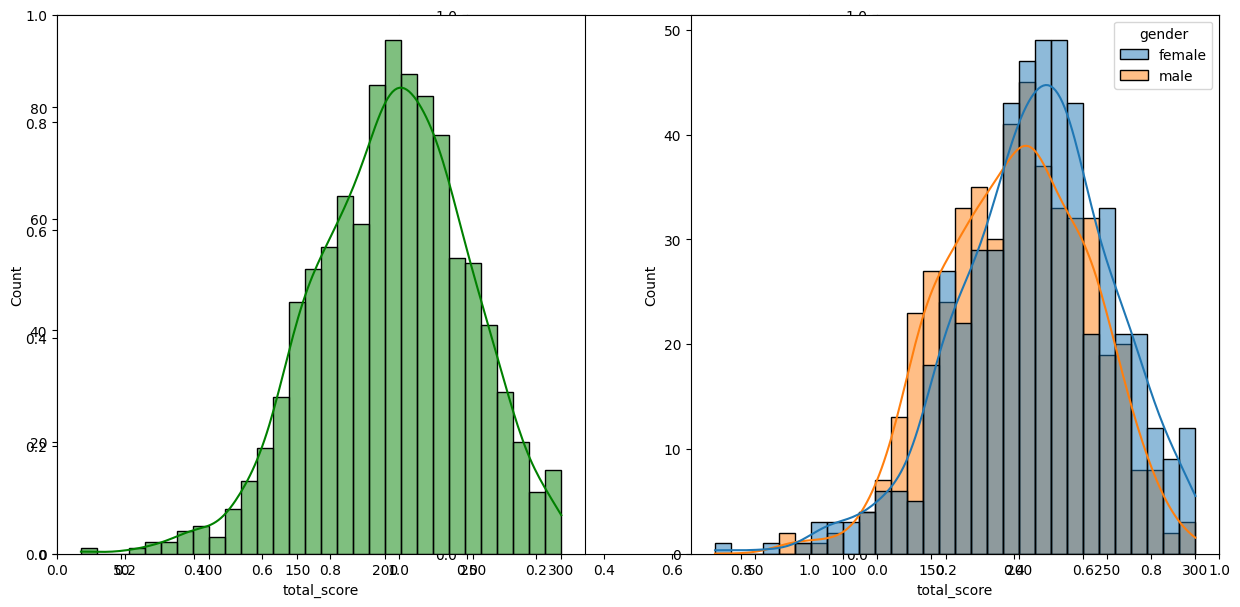

In [74]:
fig, ax = plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='total_score',bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score',bins=30, kde=True, hue='gender')
plt.show()


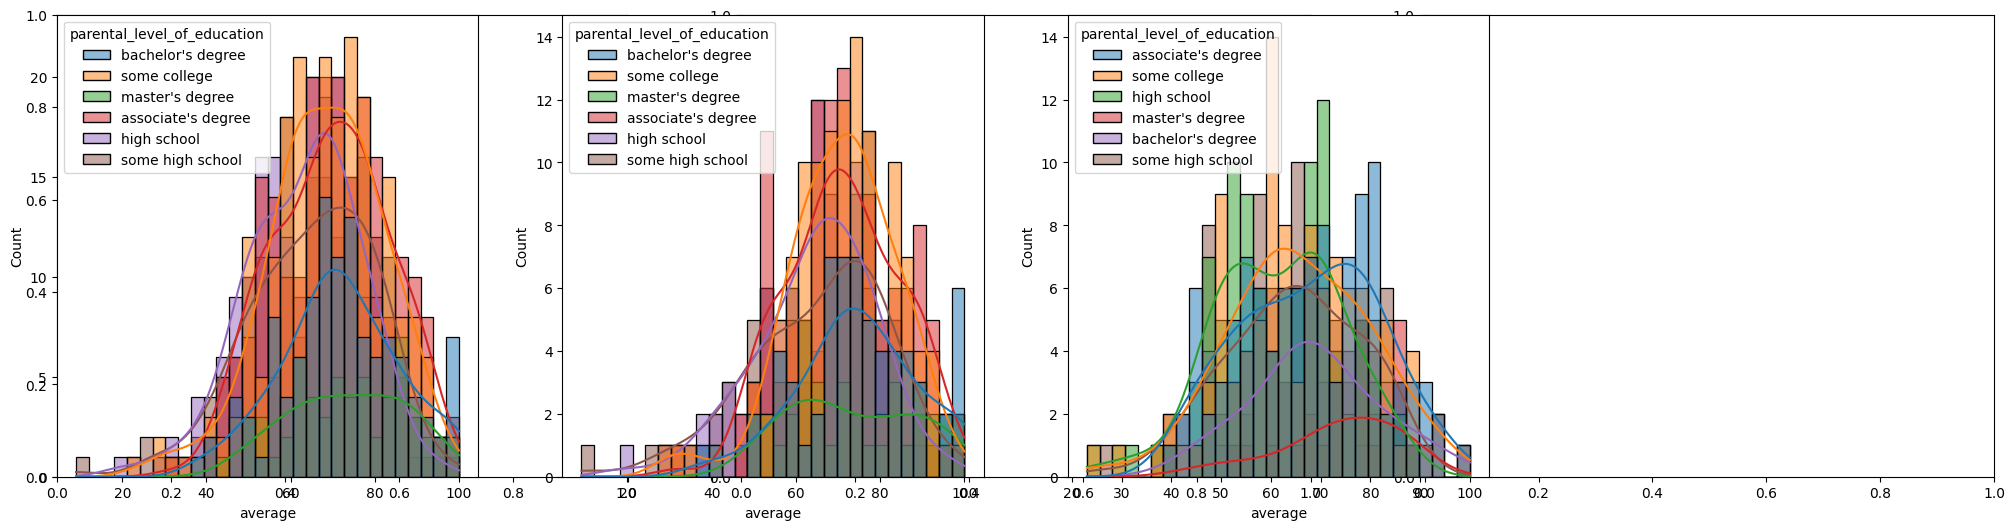

In [75]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax= sns.histplot(data=df, x='average',bins=30, kde=True, hue='parental_level_of_education')
plt.subplot(142)
ax= sns.histplot(data=df[df['gender']=='female'], x='average',bins=30, kde=True, hue='parental_level_of_education')
plt.subplot(143)
ax= sns.histplot(data=df[df['gender']=='male'], x='average',bins=30, kde=True, hue='parental_level_of_education')
plt.show()

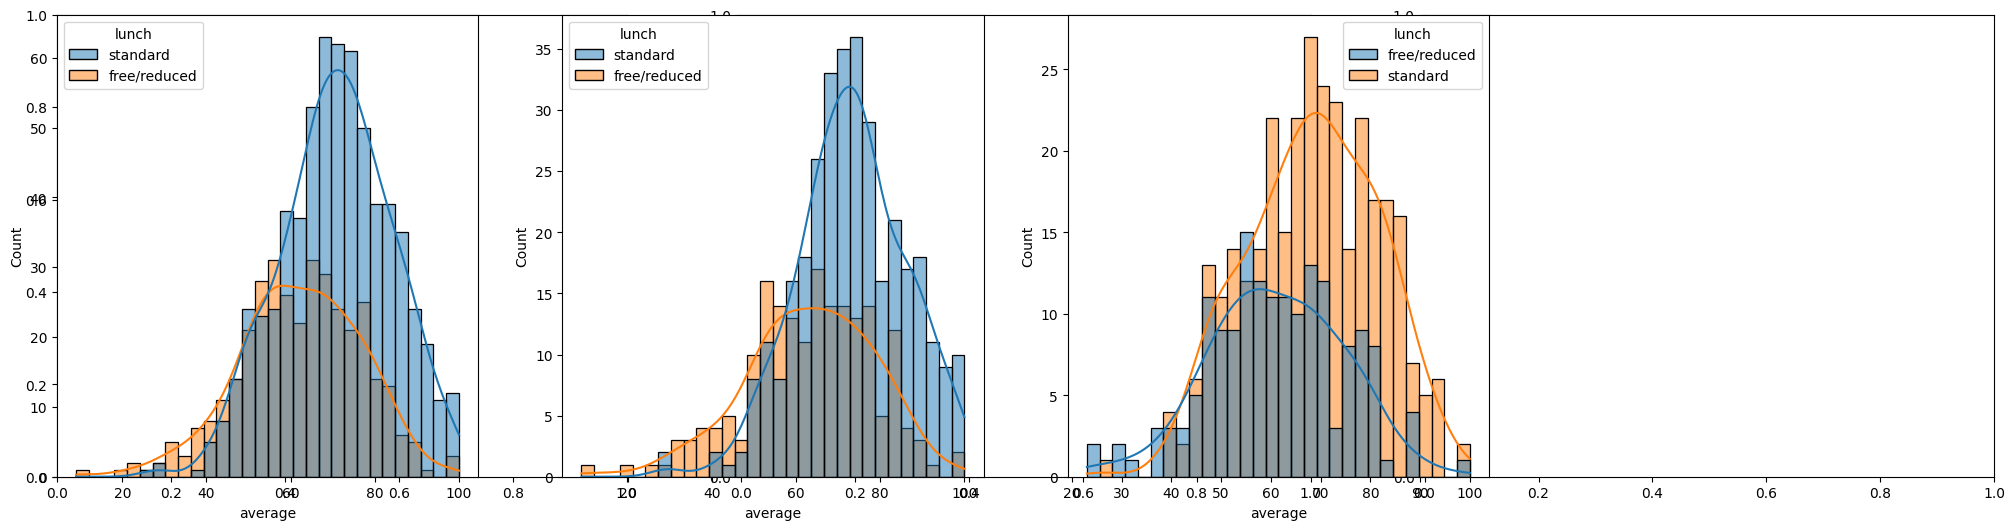

In [76]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax= sns.histplot(data=df, x='average',bins=30, kde=True, hue='lunch')
plt.subplot(142)
ax= sns.histplot(data=df[df['gender']=='female'], x='average',bins=30, kde=True, hue='lunch')
plt.subplot(143)
ax= sns.histplot(data=df[df['gender']=='male'], x='average',bins=30, kde=True, hue='lunch')
plt.show()


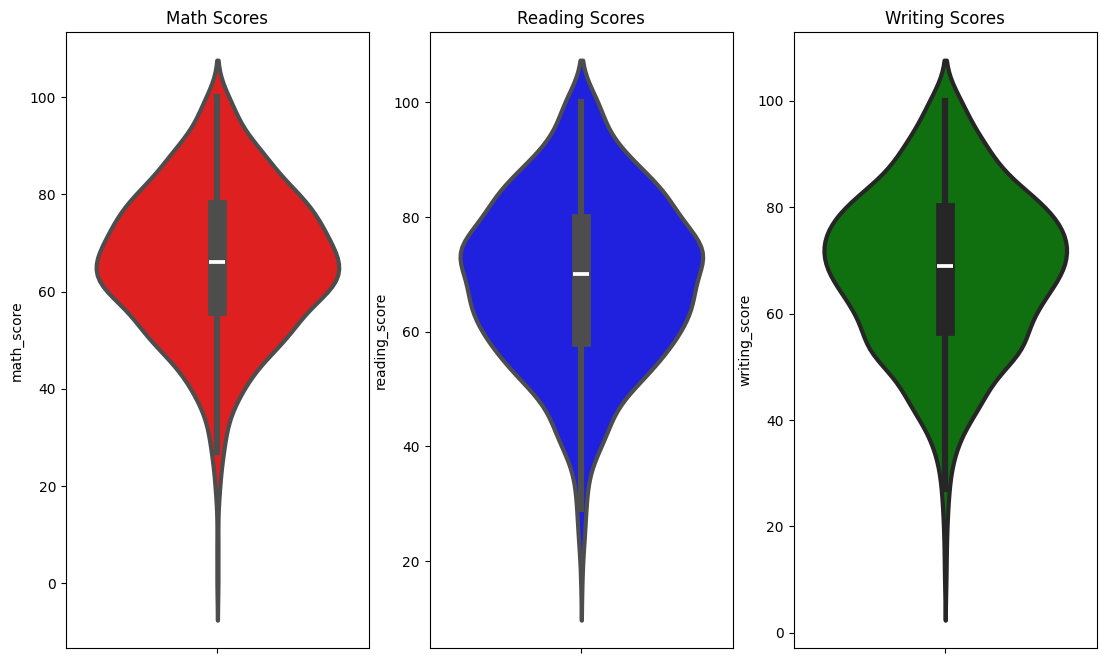

In [77]:
plt.figure(figsize=(18, 8))
plt.subplot(141)
plt.title('Math Scores')
sns.violinplot(y='math_score', data=df,color='red',linewidth=3)
plt.subplot(142)
plt.title('Reading Scores') 
sns.violinplot(y='reading_score', data=df,color='blue',linewidth=3)
plt.subplot(143)
plt.title('Writing Scores')
sns.violinplot(y='writing_score', data=df,color='green',linewidth=3)
plt.show()

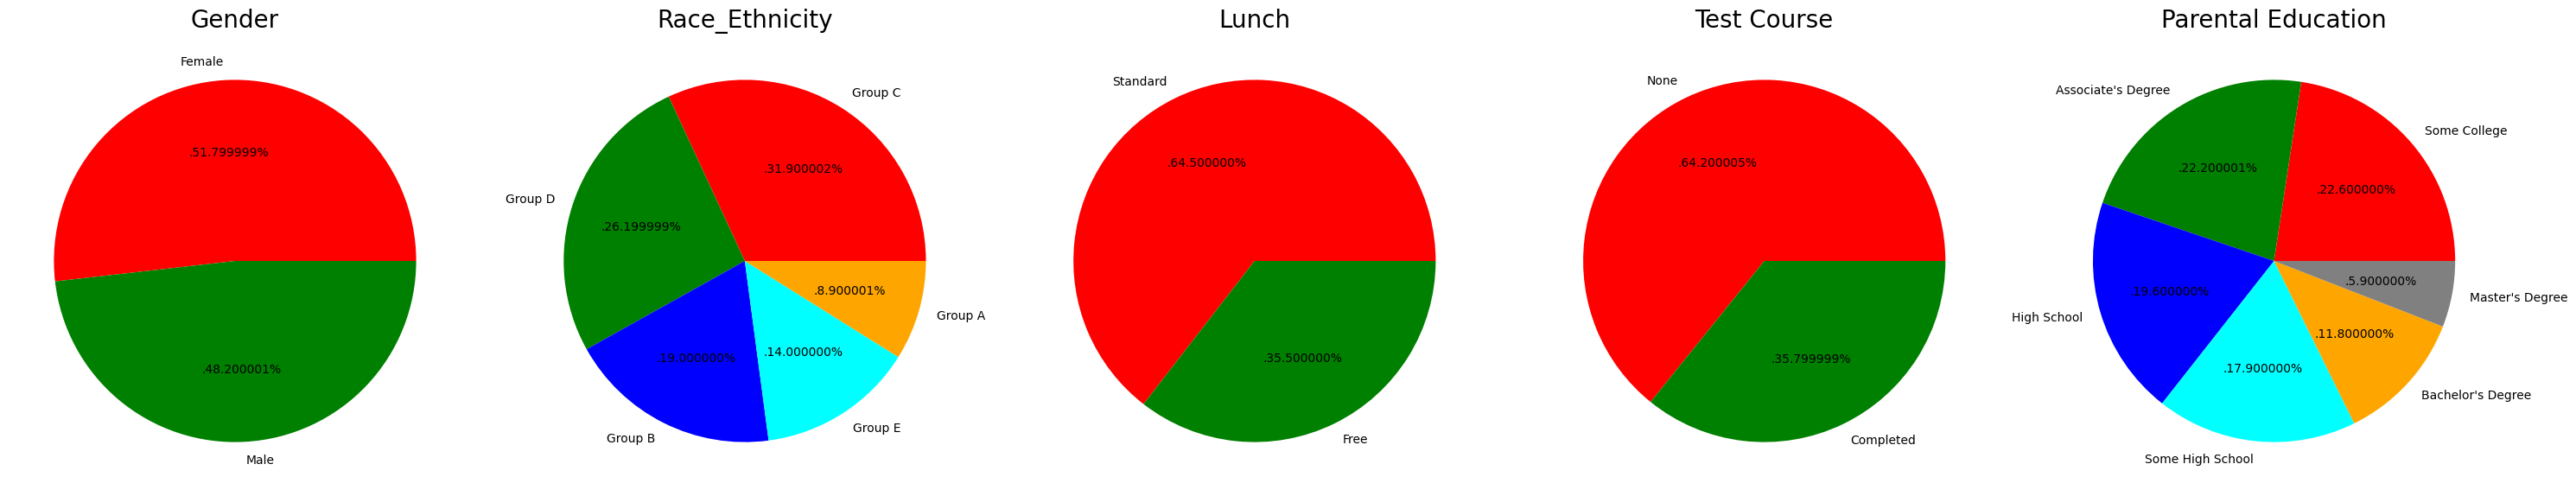

In [78]:
#Multivariate Analysis
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 5)
size = df[ 'parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

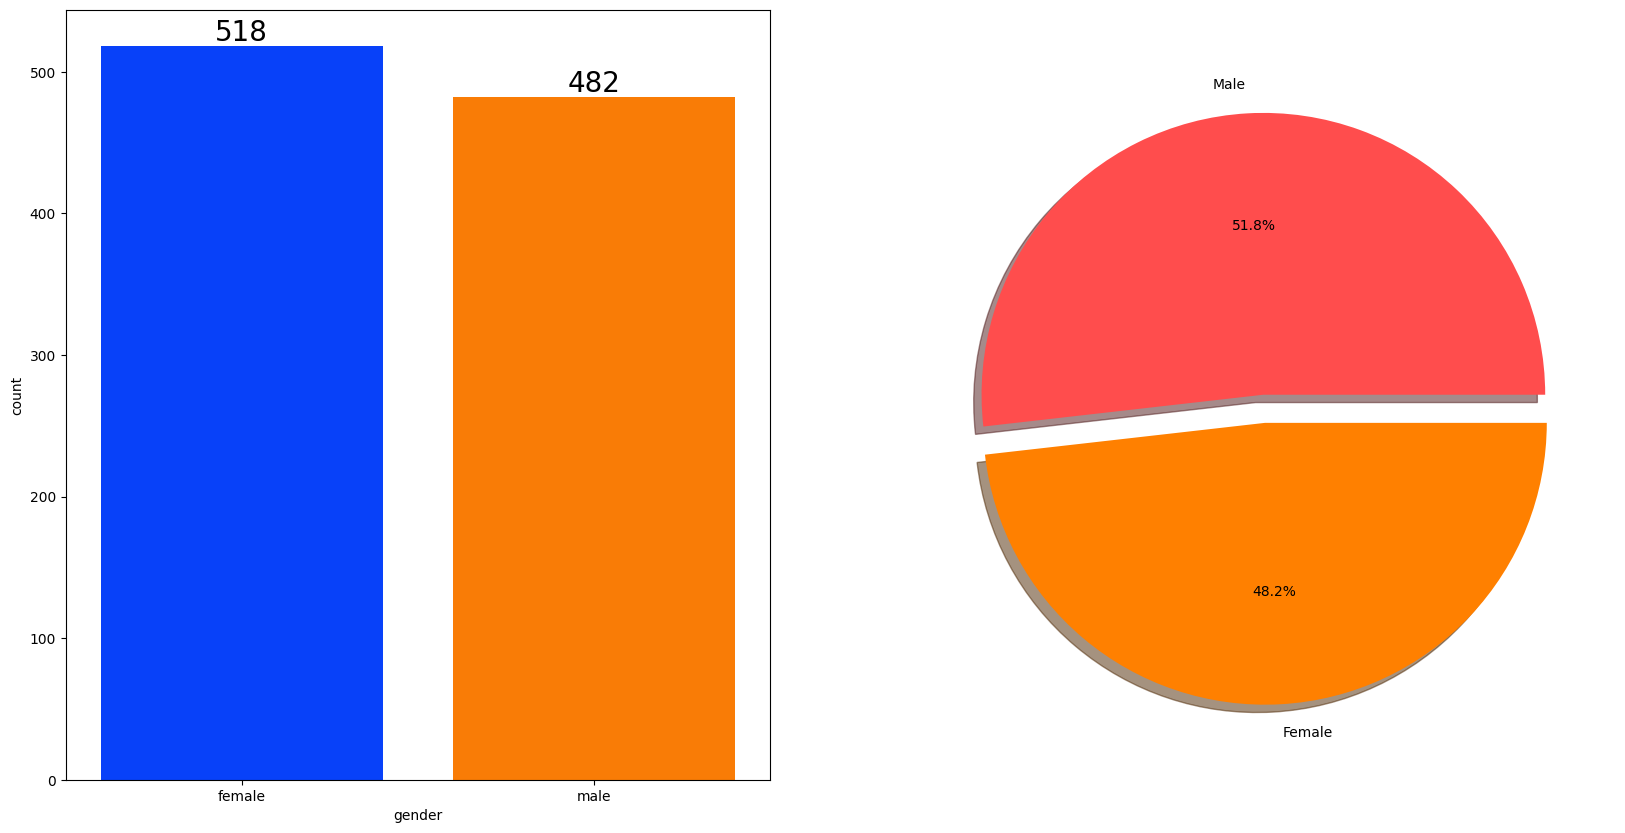

In [80]:
#Univariate Analysis
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()



In [82]:
#bivariate analysis
gender_group = df.groupby('gender').size()
gender_group    

gender
female    518
male      482
dtype: int64

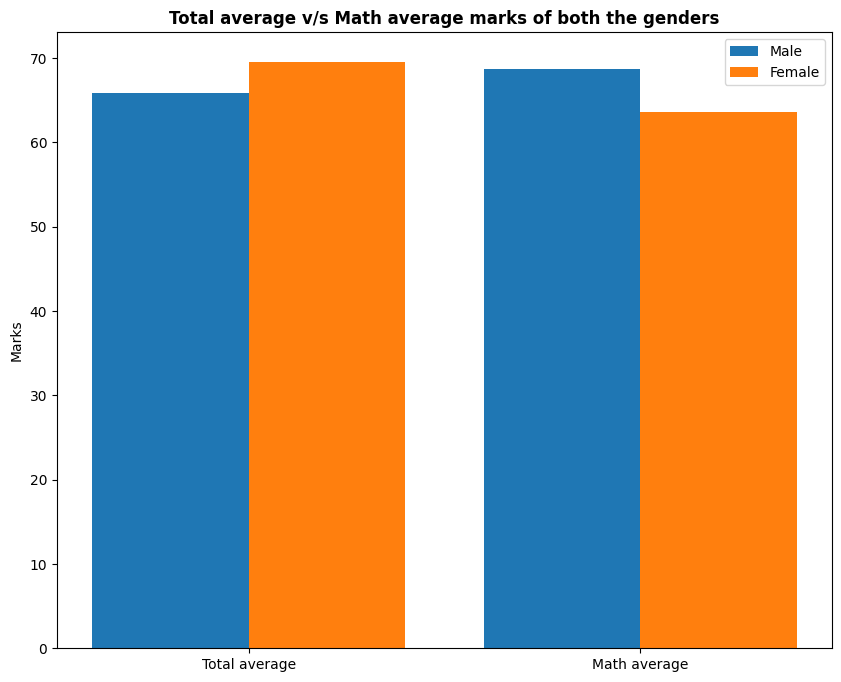

In [86]:


plt.figure(figsize=(10, 8))

X = ['Total average','Math average']

gender_mean = df.groupby('gender')[['average', 'math_score']].mean()

female_scores = [gender_mean.loc['female', 'average'], gender_mean.loc['female', 'math_score']]
male_scores = [gender_mean.loc['male', 'average'], gender_mean.loc['male', 'math_score']]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

